<a href="https://colab.research.google.com/github/MosaddikHabib/machine-Learning/blob/main/emotion_recognition_from_speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATASET_PATH = "/content/drive/MyDrive/Code Alpha/Task_02/data_set"

In [4]:
EMOTIONS = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

In [5]:
# Function to extract MFCC features
def extract_features(file_path, max_pad_length=174):
    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    pad_width = max_pad_length - mfccs.shape[1]
    if pad_width > 0:
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :max_pad_length]
    return mfccs

In [6]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.9 MB/s eta 0:00:00


In [7]:
import resampy

In [8]:
# Load dataset
X, Y = [], []
for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            emotion_label = EMOTIONS[file.split("-")[2]]  # Extract emotion from filename
            file_path = os.path.join(root, file)
            features = extract_features(file_path)
            X.append(features)
            Y.append(emotion_label)

In [9]:
# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

In [10]:
# Encode labels
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y)
Y_categorical = keras.utils.to_categorical(Y_encoded)

In [11]:
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_categorical, test_size=0.2, random_state=42)

In [12]:
# Reshape for CNN input
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]


In [13]:
# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(40, 174, 1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')
])


In [14]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [15]:
# Train model
epochs = 30
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=epochs, batch_size=32)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 335ms/step - accuracy: 0.1427 - loss: 19.9005 - val_accuracy: 0.2431 - val_loss: 1.9347
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 319ms/step - accuracy: 0.2001 - loss: 1.9408 - val_accuracy: 0.3194 - val_loss: 1.7523
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 323ms/step - accuracy: 0.3375 - loss: 1.7041 - val_accuracy: 0.4427 - val_loss: 1.4773
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 338ms/step - accuracy: 0.4910 - loss: 1.3603 - val_accuracy: 0.6007 - val_loss: 1.1822
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 339ms/step - accuracy: 0.6344 - loss: 1.0321 - val_accuracy: 0.7257 - val_loss: 0.8351
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 323ms/step - accuracy: 0.7558 - loss: 0.6920 - val_accuracy: 0.7969 - val_loss: 0.6487
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 324ms/step - accuracy: 0.8344 - loss: 0.4793 - val_accuracy: 0.8594 - val_loss: 0.5116
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 319ms/step - accuracy: 0.8732 - loss: 0.3551 - val_acc

In [16]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {accuracy:.2f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9424 - loss: 0.3166
Test Accuracy: 0.93


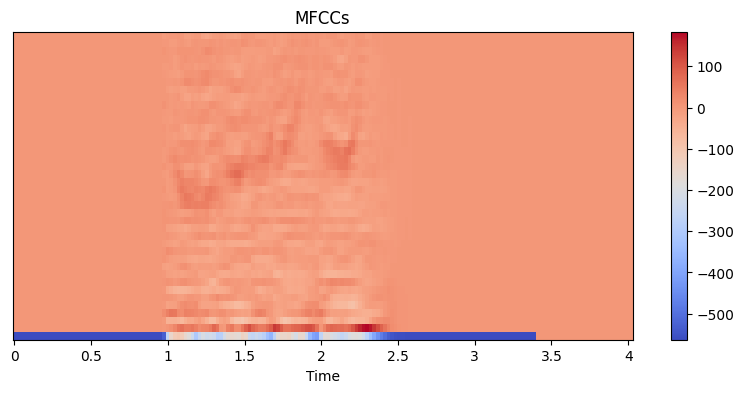

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
Predicted emotion: angry


In [17]:
# prompt: test voice from the dataset

import librosa
import IPython.display as ipd

# Choose a random index from the test set
random_index = random.randint(0, len(X_test) - 1)

# Get the file path corresponding to the random index
# Note: You'll need to map the random index back to the original file paths
# The following assumes you kept track of file paths during data loading
# Replace this with your actual mapping mechanism
# file_path =  # Your mapping logic here to get the original file path from the index
# Instead of mapping, let's just display the features directly
features = X_test[random_index]

# Reshape features for librosa display
features_reshaped = np.squeeze(features, axis=-1)

# Display the MFCCs
plt.figure(figsize=(10, 4))
librosa.display.specshow(features_reshaped, sr=22050, x_axis='time')
plt.colorbar()
plt.title('MFCCs')
plt.show()


# Predict the emotion
prediction = model.predict(np.expand_dims(X_test[random_index], axis=0))
predicted_label = encoder.inverse_transform([np.argmax(prediction)])[0]

print(f"Predicted emotion: {predicted_label}")

# (Optional) Play the audio if you have the file path
# ipd.Audio(file_path)


In [ ]:
# Save model
model.save("emotion_recognition_model.h5")